# Fake News Detection using Machine Learning

## Phase 1: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to understand the ISOT Fake News Dataset before applying preprocessing or machine learning algorithms.

In this notebook, we will:

- Load the dataset
- Inspect its structure
- Analyze class distribution
- Check for missing values
- Explore important features
- Record observations that will guide preprocessing and model development

In [1]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# Load the Dataset
# ============================================

fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")

print("Fake News Dataset Shape :", fake_df.shape)
print("True News Dataset Shape :", true_df.shape)

Fake News Dataset Shape : (23481, 4)
True News Dataset Shape : (21417, 4)


In [3]:
# Display first 5 rows of Fake News dataset
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former...",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia inve...",News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Security Secretary in Donald Trump s administration, has an email scandal of his own.In...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for the fourth day in a row. The former reality show star blasted former President Bar...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope delivered his message just days after members of the United Nations condemned T...,News,"December 25, 2017"


In [4]:
# Display first 5 rows of True News dataset
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fis...",politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits on Monday: Pentagon,"WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after Pres...",politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',"WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election campaign should continue without interference in 2018, despite calls from some ...",politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat tip-off: NYT,"WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russia had political dirt on Democratic presidential candidate Hillary Clinton, the N...",politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much more' for Amazon shipments,"SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Service on Friday to charge “much more” to ship packages for Amazon (AMZN.O), picking another fight with an online r...",politicsNews,"December 29, 2017"


In [5]:
# ============================================
# Dataset Information
# ============================================

print("Fake News Dataset Information")
fake_df.info()

print("\n" + "="*60 + "\n")

print("True News Dataset Information")
true_df.info()

Fake News Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


True News Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


In [6]:
# ============================================
# Missing Values
# ============================================

print("Missing values in Fake News Dataset")
print(fake_df.isnull().sum())

print("\n" + "="*60 + "\n")

print("Missing values in True News Dataset")
print(true_df.isnull().sum())

Missing values in Fake News Dataset
title      0
text       0
subject    0
date       0
dtype: int64


Missing values in True News Dataset
title      0
text       0
subject    0
date       0
dtype: int64


## Observations

- Both datasets contain four columns: title, text, subject, and date.
- No missing values were observed.
- The `text` column contains the complete news article.
- The `title` provides a concise summary.
- All columns appear to have the correct data types.

In [11]:
# ============================================
# Create Labels
# ============================================

fake_df["label"] = 0
true_df["label"] = 1

In [12]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former...",News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia inve...",News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Security Secretary in Donald Trump s administration, has an email scandal of his own.In...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for the fourth day in a row. The former reality show star blasted former President Bar...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope delivered his message just days after members of the United Nations condemned T...,News,"December 25, 2017",0


In [13]:
# ============================================
# Combine Fake and True News
# ============================================

df = pd.concat([fake_df, true_df], ignore_index=True)

print("Combined Dataset Shape:", df.shape)

Combined Dataset Shape: (44898, 5)


In [14]:
# ============================================
# Shuffle Dataset
# ============================================

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocati...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Security Council,"WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year t...",politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,"(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can provide aid to the is...",politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO),"On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to Russia earlier this month.While it ...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a golf resort,"GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credentials. Donald Trump arrives in Scotland on Friday to reopen a golf resort. The presu...",politicsNews,"June 24, 2016",1


shuffled the dataset


In [15]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


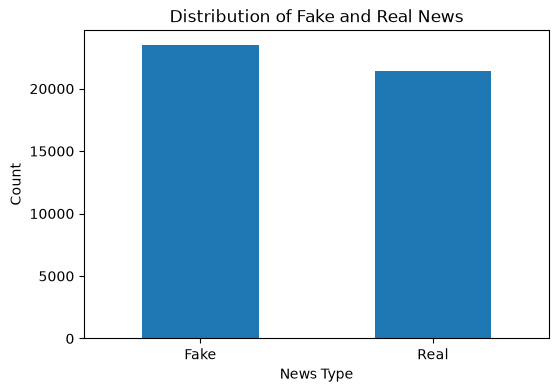

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar")

plt.xticks([0,1], ["Fake","Real"], rotation=0)

plt.xlabel("News Type")
plt.ylabel("Count")
plt.title("Distribution of Fake and Real News")

plt.show()

## Observations

- The datasets were successfully combined into a single dataframe.
- A binary label was assigned to each article.
- The combined dataset contains approximately 45,000 news articles.
- The dataset is fairly balanced, which is beneficial for binary classification.
- Shuffling removes any ordering bias before model training.

In [17]:
# Display one article before preprocessing

print(df.loc[0, "text"])

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK BY SUBSCRIBING & 

In [18]:
import re

In [19]:
# ============================================
# Text Cleaning Function
# ============================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [20]:
df["clean_text"] = df["text"].apply(clean_text)

In [21]:
print("Before Cleaning:\n")
print(df.loc[0, "text"])

print("\n" + "="*80 + "\n")

print("After Cleaning:\n")
print(df.loc[0, "clean_text"])

Before Cleaning:

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK

# Phase 4: Feature Extraction using TF-IDF

## Objective

Machine learning algorithms cannot directly process text. Therefore, the cleaned news articles are converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.

TF-IDF assigns higher importance to words that are frequent in a document but rare across the entire dataset, helping the model focus on informative terms.

In [22]:
# ============================================
# Feature Extraction using TF-IDF
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = tfidf.fit_transform(df["clean_text"])

y = df["label"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (44898, 5000)
Target Shape: (44898,)


In [41]:
%whos

Variable                 Type                  Data/Info
--------------------------------------------------------
ConfusionMatrixDisplay   type                  <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LinearSVC                type                  <class 'sklearn.svm._classes.LinearSVC'>
LogisticRegression       type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MultinomialNB            ABCMeta               <class 'sklearn.naive_bayes.MultinomialNB'>
TfidfVectorizer          type                  <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
WordCloud                type                  <class 'wordcloud.wordcloud.WordCloud'>
X                        csr_matrix            <Compressed Sparse Row sp<...> 1156)	0.0996316280992673
X_test                   csr_matrix            <Compressed Sparse Row sp<...> 1372)	0.0849503224525301
X_train                  csr_matrix            <Compressed Sparse Row sp<...>2572)	0.23316797208143117
ac

# Phase 5: Train-Test Split

## Objective

Split the dataset into training and testing sets to evaluate how well the model generalizes to unseen news articles.

The model will learn from the training set and will be evaluated only on the testing set.

In [23]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (35918, 5000)
Testing Features  : (8980, 5000)

Training Labels : (35918,)
Testing Labels  : (8980,)


# Phase 6: Logistic Regression

## Objective

Train a Logistic Regression classifier on the TF-IDF feature vectors to distinguish between fake and real news articles.

In [24]:
# ============================================
# Logistic Regression Model
# ============================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [40]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained Logistic Regression model
joblib.dump(lr_model, "../models/logistic_regression.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("Vectorizer saved successfully!")

NameError: name 'vectorizer' is not defined

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9890


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# Phase 6: Model Comparison

In this phase, we compare multiple machine learning algorithms for fake news detection.

In [27]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))
print()
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.99543429844098

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [28]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print()
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9420935412026726

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4696
           1       0.94      0.94      0.94      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



In [29]:
comparison = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Linear SVM": accuracy_score(y_test, svm_pred),
    "Naive Bayes": accuracy_score(y_test, nb_pred)
}

comparison

{'Logistic Regression': 0.9889755011135858,
 'Linear SVM': 0.99543429844098,
 'Naive Bayes': 0.9420935412026726}

Phase 7 – Visualizations

We'll create visualizations one by one and save each in the results/ folder.

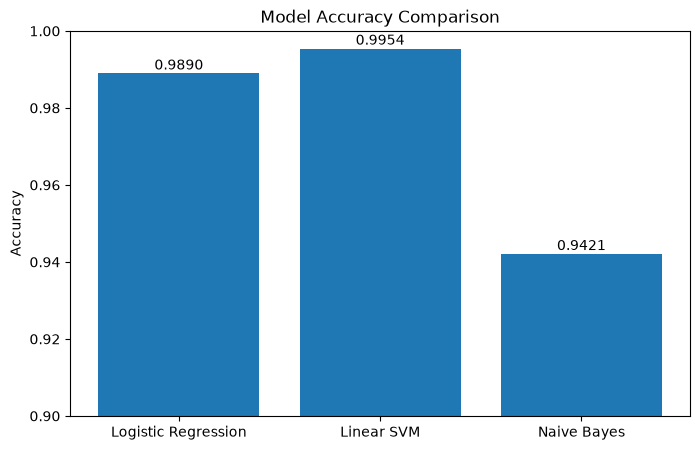

In [30]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Linear SVM", "Naive Bayes"]

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, nb_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9,1.0)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.001, f"{value:.4f}", ha="center")

plt.savefig("../results/model_accuracy_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 600x600 with 0 Axes>

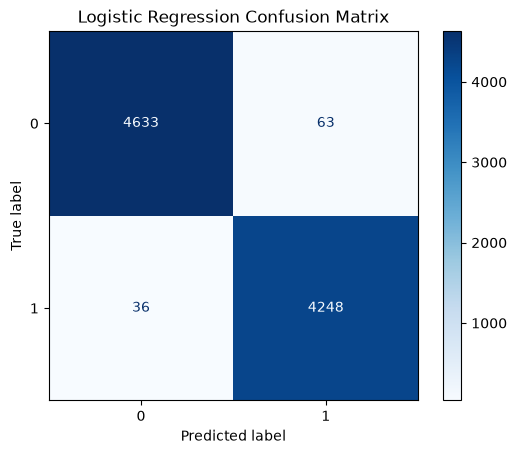

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig("../results/confusion_lr.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 600x600 with 0 Axes>

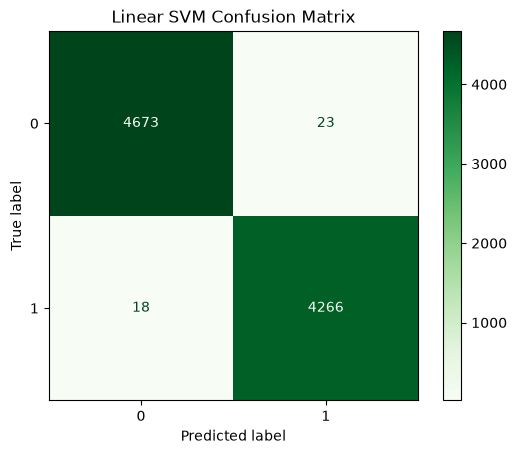

In [32]:
plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="Greens"
)

plt.title("Linear SVM Confusion Matrix")

plt.savefig("../results/confusion_svm.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 600x600 with 0 Axes>

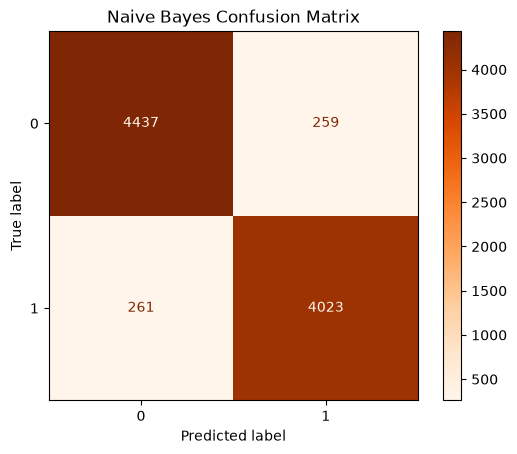

In [33]:
plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred,
    cmap="Oranges"
)

plt.title("Naive Bayes Confusion Matrix")

plt.savefig("../results/confusion_nb.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [34]:
import sys
!{sys.executable} -m pip install wordcloud

In [35]:
from wordcloud import WordCloud
print("WordCloud installed successfully!")

WordCloud installed successfully!


In [36]:
df.head()

,title,text,subject,date,label,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocati...",US_News,"February 13, 2017",0,st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative sta...
1,Trump drops Steve Bannon from National Security Council,"WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year t...",politicsNews,"April 5, 2017",1,washington reuters us president donald trump removed his chief strategist steve bannon from the national security council on wednesday reversing his controversial decision early this year to give ...
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,"(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can provide aid to the is...",politicsNews,"September 27, 2017",1,reuters puerto rico governor ricardo rossello said on wednesday he expected the federal government to waive the jones act which would lift restrictions on ships that can provide aid to the island ...
3,OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO),"On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to Russia earlier this month.While it ...",News,"May 22, 2017",0,on monday donald trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to russia earlier this monthwhile it wa...
4,Donald Trump heads for Scotland to reopen a golf resort,"GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credentials. Donald Trump arrives in Scotland on Friday to reopen a golf resort. The presu...",politicsNews,"June 24, 2016",1,glasgow scotland reuters most us presidential candidates go abroad to sharpen their foreign policy credentials donald trump arrives in scotland on friday to reopen a golf resort the presumptive re...


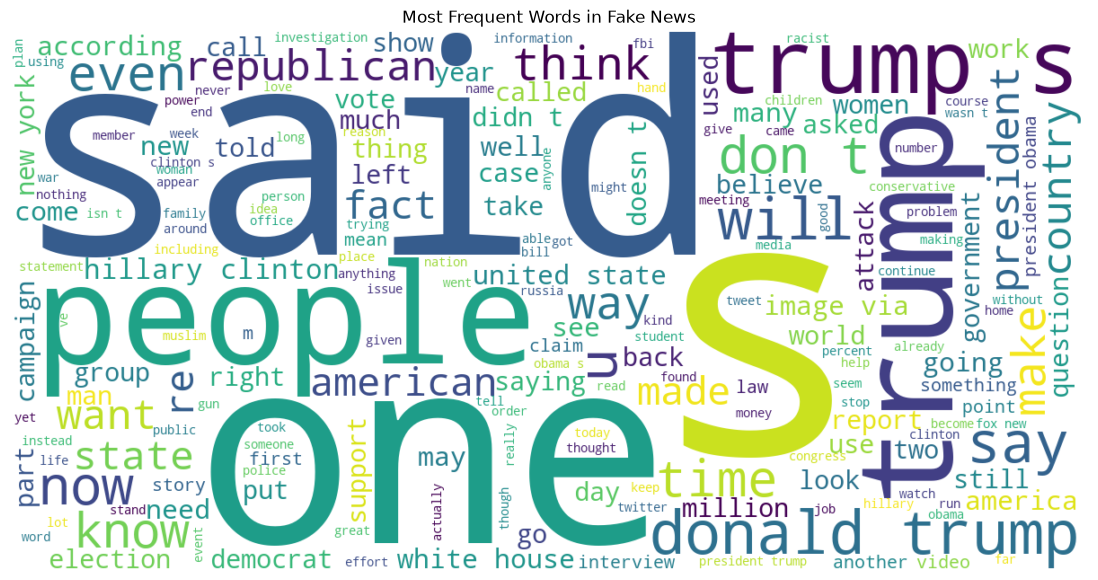

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = " ".join(df[df["label"] == 0]["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(fake_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Fake News")

plt.savefig("../results/fake_wordcloud.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

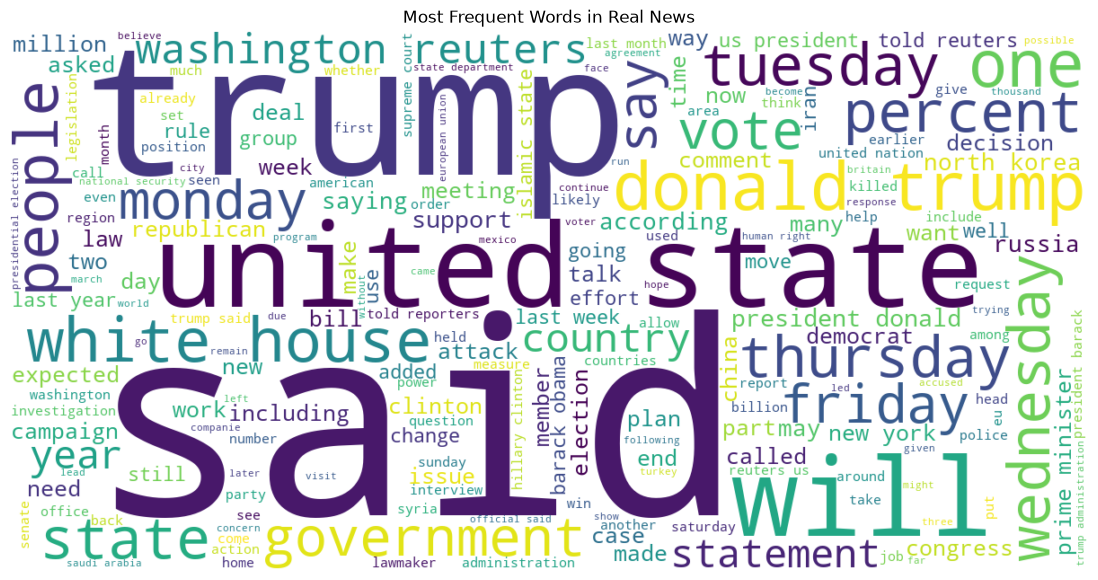

In [38]:
real_text = " ".join(df[df["label"] == 1]["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(real_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Real News")

plt.savefig("../results/real_wordcloud.png",
            dpi=300,
            bbox_inches="tight")

plt.show()